# EDS API — Consumption-Weighted Spot Price Fetcher

This notebook demonstrates a fetcher built on top of the [Energidataservice (EDS) API](https://www.energidataservice.dk/). It solves a concrete data problem: **the Danish spot price history is split across two datasets**, requiring stitching and consumption-weighting to produce a single, coherent price series for DK.

In [1]:
!pip install ET-eds-api --upgrade --quiet

from ET_eds_api import get_wp_h, wagg_wp, VE, columns

---

## The Dataset Problem

EDS publishes spot prices across **two separate datasets**:

| Dataset | Coverage | Price column | Time column |
|---|---|---|---|
| [`Elspotprices`](https://www.energidataservice.dk/tso-electricity/Elspotprices) | Historical — up to ~2025-09-30 | `SpotPriceDKK` | `HourUTC` |
| [`DayAheadPrices`](https://www.energidataservice.dk/tso-electricity/DayAheadPrices) | From ~2025-10-01 onwards | `DayAheadPriceDKK` | `TimeUTC` (15-min resolution) |

Beyond the dataset split, `DayAheadPrices` reports at **15-minute resolution**, so it must be averaged to hourly before combining.

A third dataset, [`ProductionConsumptionSettlement`](https://www.energidataservice.dk/tso-electricity/ProductionConsumptionSettlement), provides hourly `GrossConsumptionMWh` per price area. This is used to compute a **consumption-weighted average** across DK1 and DK2, rather than a simple mean.

---

## `get_wp_h` — Hourly Weighted Price

Returns three DataFrames:

- `wp_h` — hourly consumption-weighted spot price for Denmark (DKK/MWh)
- `q_h` — hourly total gross consumption (MWh)
- `p_area` — hourly price per price area (wide: one column per area)

The stitching logic:
1. Fetch `Elspotprices` (hourly, historical)
2. Fetch `DayAheadPrices` (15-min), resample to hourly mean
3. Concatenate the two into a single price series
4. Merge in `GrossConsumptionMWh` per area
5. Compute weighted price: `Σ(price × consumption) / Σ(consumption)`

Pass `cache=True` to save responses as parquet in `eds_cache/` — subsequent calls load from disk instantly.

In [5]:
wp_h, q_h, p_area = get_wp_h(start="2024", end="2026", cache=True)

print(f"Price rows: {len(wp_h)}, Quantity rows: {len(q_h)}")
wp_h.tail()

Price rows: 17544, Quantity rows: 17544


,HourUTC,SpotPriceDKK_weighted
17539,2025-12-31 19:00:00,629.855386
17540,2025-12-31 20:00:00,590.077723
17541,2025-12-31 21:00:00,545.275276
17542,2025-12-31 22:00:00,478.865497
17543,2025-12-31 23:00:00,435.242098


In [6]:
q_h.tail()

,HourUTC,GrossConsumptionMWh
17539,2025-12-31 19:00:00,4842.855811
17540,2025-12-31 20:00:00,4629.903406
17541,2025-12-31 21:00:00,4453.289972
17542,2025-12-31 22:00:00,4428.452105
17543,2025-12-31 23:00:00,5044.059379


In [7]:
# Area-specific prices — one column per price area
p_area.tail()

,HourUTC,DK1,DK2
17539,2025-12-31 19:00:00,619.900024,644.192640
17540,2025-12-31 20:00:00,585.785829,596.298313
17541,2025-12-31 21:00:00,545.229700,545.341730
17542,2025-12-31 22:00:00,495.281431,454.183803
17543,2025-12-31 23:00:00,435.268822,435.194138


### Verifying the stitch

Filter to the 3-day window around the boundary and check the length. A clean stitch gives exactly 73 rows (3 days × 24 h + 1 h) — no gap, no duplicates.

In [8]:
boundary = wp_h[
    (wp_h["HourUTC"] >= "2025-09-29") &
    (wp_h["HourUTC"] <= "2025-10-02")
]

# 3 days × 24 h + 1 = 73 — confirms no gap, no duplicates
len(boundary)

73

---

## `wagg_wp` — Aggregating to Daily, Weekly, Monthly, Yearly

`wagg_wp` wraps `get_wp_h` and re-applies the same consumption-weighting formula at coarser time resolutions:

```
weighted_price = Σ(hourly_price × hourly_consumption) / Σ(hourly_consumption)
```

This matters because a simple mean of daily averages treats a cheap 3 AM hour the same as a peak 6 PM hour. Weighting by `GrossConsumptionMWh` ensures each period's price reflects what Denmark actually paid on average.

| Output | Period key | Typical use |
|---|---|---|
| `wp_d` | `date` (Day) | Short-term price trends |
| `wp_w` | `week` (ISO week) | Weekly reporting |
| `wp_m` | `month` | Billing / invoice benchmarking |
| `wp_y` | `year` | Annual summaries |

In [10]:
wp_d, wp_w, wp_m, wp_y = wagg_wp(start="2024-01-01", end="2026-01-01")

In [11]:
import pandas as pd

# Side-by-side overview of all aggregation levels
for label, df, col in [
    ("Daily",   wp_d.head(), "date"),
    ("Weekly",  wp_w.head(), "week"),
    ("Monthly", wp_m.head(), "month"),
    ("Yearly",  wp_y.head(), "year"),
]:
    print(f"── {label} ──────────────────────────────────")
    print(df.to_string(index=False))
    print()

── Daily ──────────────────────────────────
      date  SpotPriceDKK_weighted
2024-01-01             265.172191
2024-01-02             413.847341
2024-01-03             380.991593
2024-01-04             659.895641
2024-01-05            1014.850486

── Weekly ──────────────────────────────────
                 week  SpotPriceDKK_weighted
2024-01-01/2024-01-07             590.979988
2024-01-08/2024-01-14             744.087182
2024-01-15/2024-01-21             648.258895
2024-01-22/2024-01-28             385.990850
2024-01-29/2024-02-04             333.482249

── Monthly ──────────────────────────────────
  month  SpotPriceDKK_weighted
2024-01             579.623222
2024-02             428.548295
2024-03             456.197797
2024-04             435.115725
2024-05             412.257619

── Yearly ──────────────────────────────────
 year  SpotPriceDKK_weighted
 2024             525.317985
 2025             602.424481



In [12]:
print("Monthly weighted prices (DKK/MWh):")
wp_m.head()

Monthly weighted prices (DKK/MWh):


,month,SpotPriceDKK_weighted
0,2024-01,579.623222
1,2024-02,428.548295
2,2024-03,456.197797
3,2024-04,435.115725
4,2024-05,412.257619


In [13]:
print("Yearly weighted prices (DKK/MWh):")
wp_y

Yearly weighted prices (DKK/MWh):


,year,SpotPriceDKK_weighted
0,2024,525.317985
1,2025,602.424481


---

## Quick Plot

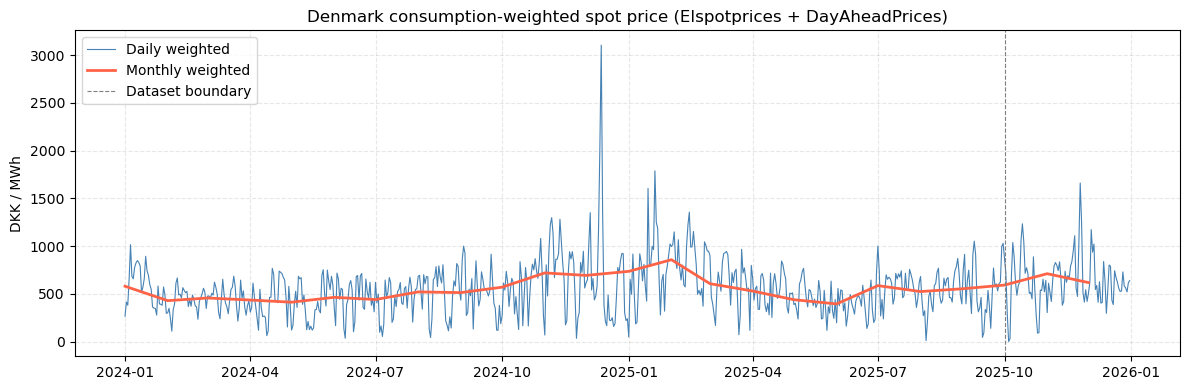

In [14]:
import matplotlib.pyplot as plt
import pandas as pd

fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(
    wp_d["date"].dt.to_timestamp(),
    wp_d["SpotPriceDKK_weighted"],
    linewidth=0.8,
    color="steelblue",
    label="Daily weighted"
)
ax.plot(
    wp_m["month"].dt.to_timestamp(),
    wp_m["SpotPriceDKK_weighted"],
    linewidth=2,
    color="tomato",
    label="Monthly weighted"
)
ax.axvline(
    pd.Timestamp("2025-10-01"),
    color="grey", linestyle="--", linewidth=0.8, label="Dataset boundary"
)

ax.set_ylabel("DKK / MWh")
ax.set_title("Denmark consumption-weighted spot price (Elspotprices + DayAheadPrices)")
ax.legend()
ax.grid(alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()